# Ablation Study — Enhancement-by-Enhancement Analysis
### Autonomous Highway Driving with PPO

This notebook trains and evaluates **7 configurations** to isolate the contribution of each enhancement.
Each run uses the **same seed, same evaluation protocol, and same architecture** — only the active
enhancement changes.

| Run | Enhancement | Timesteps | Why this budget |
|-----|-------------|----------:|----------------|
| Baseline | None | 200k | Reference point |
| E1 | Enhanced Reward (TTC + smooth + lane-center) | 200k | Same env difficulty as baseline |
| E2 | Dynamic Traffic (variable density + events) | 500k | Harder env needs more data |
| E3 | Observation Enrichment (7 -> 10 features) | 500k | Larger input space needs more data |
| E4 | Attention Regularization (entropy penalty) | 200k | Same env difficulty as baseline |
| All | All 4 enhancements combined | 500k | Previous 200k run failed; giving it more time |
| E3+E4 | E3 + E4 combined (the two individual winners) | 500k | Testing whether the two best enhancements compound |

**Run each cell in order.** Each run section explains what the enhancement does, what to expect,
then prints live training output followed by a full metrics breakdown after evaluation.

---
## Step 1 — Install Dependencies

In [1]:
import subprocess, sys

packages = [
    'gymnasium>=0.29.0',
    'stable-baselines3>=2.0.0',
    'highway-env>=1.8.0',
    'torch>=2.0.0',
    'pygame>=2.5.0',
    'seaborn>=0.12.0',
    'numpy>=1.24.0',
    'tensorboard>=2.13.0',
    'matplotlib',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

print('All packages installed.')

All packages installed.


---
## Step 2 — Imports & Global Configuration

In [ ]:
import os, sys, json
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')   # headless-safe; works on Colab
from IPython.display import display, Image

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import highway_env  # noqa -- registers highway-v0

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback

from src.models.baseline_model import CustomExtractor, env_kwargs
from src.models.custom_policy import AttentionRegularizedPPO
from src.evaluation.evaluation_metrics import MetricsEvaluator, compute_learning_efficiency
from scripts.train_enhanced import (
    make_enhanced_env,
    _BASELINE_ATTN_KWARGS,
    _ENHANCED_ATTN_KWARGS,
)

# ---------------------------------------------------------------------------
# Global settings
# ---------------------------------------------------------------------------
N_CPU           = 32     # parallel envs via SubprocVecEnv on HPC
N_EVAL_EPISODES = 30     # 30 episodes is statistically solid and 3x faster
SEED            = 42
LOG_DIR         = '../ablation_logs'
RESULTS_DIR     = '../ablation_results'

os.makedirs(LOG_DIR,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

# Optimal thread count for small PPO models on CPU.
# 96 threads (default) causes thrashing for tiny MLPs; 8 is much faster.
torch.set_num_threads(16)
print(f'PyTorch threads: {torch.get_num_threads()}')

# Accumulates results from every run -- populated by each evaluate cell below
run_results = {}

print('Imports complete.')


---
## Step 3 — Environment Verification
Quick smoke-test confirming that both the baseline (7-feature) and enriched (10-feature)
environments load correctly.

In [ ]:
# --- Baseline environment (no enhancements) ---
_no_enh = {'enhanced_reward': False, 'dynamic_traffic': False,
            'observation_enrichment': False, 'attention_reg': False}

test_env = make_enhanced_env(enhancements=_no_enh, **env_kwargs)
obs, info = test_env.reset()
print('Baseline environment')
print(f'  Observation shape : {obs.shape}  (vehicles x features)')
print(f'  Action space      : {test_env.action_space}')
test_env.close()

# --- Enriched environment (E3 active) ---
_e3_enh = {**_no_enh, 'observation_enrichment': True}
test_env_e3 = make_enhanced_env(enhancements=_e3_enh, **env_kwargs)
obs_e3, _ = test_env_e3.reset()
print('\nE3 enriched environment')
print(f'  Observation shape : {obs_e3.shape}  (should be 10 features)')
test_env_e3.close()

# --- Dynamic traffic environment (E2 active) ---
_e2_enh = {**_no_enh, 'dynamic_traffic': True}
test_env_e2 = make_enhanced_env(enhancements=_e2_enh, **env_kwargs)
obs_e2, info_e2 = test_env_e2.reset()
print('\nE2 dynamic traffic environment')
print(f'  Traffic scenario  : {info_e2.get("traffic_scenario", "N/A")}')
print(f'  Vehicles count    : {info_e2.get("vehicles_count", "N/A")}')
test_env_e2.close()

print('\nEnvironment check passed.')

Baseline environment
  Observation shape : (10, 7)  (vehicles x features)
  Action space      : Discrete(5)

E3 enriched environment
  Observation shape : (10, 10)  (should be 10 features)

E2 dynamic traffic environment
  Traffic scenario  : moderate
  Vehicles count    : 18

Environment check passed.


: 

: 

---
## Step 4 — Run Configurations
All 7 configurations are defined here. Each entry specifies:
- which enhancements are active
- how many timesteps to train for
- a human-readable label and colour for comparison plots

In [ ]:
RUN_CONFIGS = {
    'baseline': {
        'enhancements': {
            'enhanced_reward': False, 'dynamic_traffic': False,
            'observation_enrichment': False, 'attention_reg': False,
        },
        'timesteps':   200_000,
        'label':       'Baseline',
        'description': 'Standard PPO -- no enhancements active',
        'color':       'steelblue',
    },
    'e1_reward': {
        'enhancements': {
            'enhanced_reward': True, 'dynamic_traffic': False,
            'observation_enrichment': False, 'attention_reg': False,
        },
        'timesteps':   200_000,
        'label':       'E1: Enhanced Reward',
        'description': 'TTC penalty + smooth driving + lane-centering rewards',
        'color':       'mediumseagreen',
    },
    'e2_traffic': {
        'enhancements': {
            'enhanced_reward': False, 'dynamic_traffic': True,
            'observation_enrichment': False, 'attention_reg': False,
        },
        'timesteps':   500_000,
        'label':       'E2: Dynamic Traffic',
        'description': 'Variable vehicle density (sparse/moderate/dense) + random events',
        'color':       'darkorange',
    },
    'e3_obs': {
        'enhancements': {
            'enhanced_reward': False, 'dynamic_traffic': False,
            'observation_enrichment': True, 'attention_reg': False,
        },
        'timesteps':   500_000,
        'label':       'E3: Observation Enrichment',
        'description': 'Observation space expanded from 7 to 10 features per vehicle',
        'color':       'mediumpurple',
    },
    'e4_attn': {
        'enhancements': {
            'enhanced_reward': False, 'dynamic_traffic': False,
            'observation_enrichment': False, 'attention_reg': True,
        },
        'timesteps':   200_000,
        'label':       'E4: Attention Reg.',
        'description': 'Entropy penalty on attention weights prevents over/under-focus',
        'color':       'crimson',
    },
    'all_enhancements': {
        'enhancements': {
            'enhanced_reward': True, 'dynamic_traffic': True,
            'observation_enrichment': True, 'attention_reg': True,
        },
        'timesteps':   500_000,
        'label':       'All Enhancements',
        'description': 'All 4 enhancements active simultaneously (500k -- prev. 200k run failed)',
        'color':       'goldenrod',
    },
    'e3_e4': {
        'enhancements': {
            'enhanced_reward': False, 'dynamic_traffic': False,
            'observation_enrichment': True, 'attention_reg': True,
        },
        'timesteps':   500_000,
        'label':       'E3 + E4 Combined',
        'description': 'Observation enrichment (7->10 features) + attention regularization',
        'color':       'deeppink',
    },
}

print('Run configurations:')
print()
print(f"  {'LABEL':<26}  {'TIMESTEPS':>10}   DESCRIPTION")
print('  ' + '-' * 72)
for name, cfg in RUN_CONFIGS.items():
    print(f"  {cfg['label']:<26}  {cfg['timesteps']:>10,}   {cfg['description']}")

Run configurations:

  LABEL                        TIMESTEPS   DESCRIPTION
  ------------------------------------------------------------------------
  Baseline                       200,000   Standard PPO -- no enhancements active
  E1: Enhanced Reward            200,000   TTC penalty + smooth driving + lane-centering rewards
  E2: Dynamic Traffic            500,000   Variable vehicle density (sparse/moderate/dense) + random events
  E3: Observation Enrichment     500,000   Observation space expanded from 7 to 10 features per vehicle
  E4: Attention Reg.             200,000   Entropy penalty on attention weights prevents over/under-focus
  All Enhancements               500,000   All 4 enhancements active simultaneously (500k -- prev. 200k run failed)
  E3 + E4 Combined               500,000   Observation enrichment (7->10 features) + attention regularization


: 

: 

---
## Step 5 — Shared Helper Functions
Run this cell once. The three helpers (`train_run`, `evaluate_run`, `print_run_metrics`)
are reused by every run section below.

In [ ]:
# =============================================================================
#  _LogRewards callback
#  Records the 20-episode rolling mean reward to a list during training.
#  Also checkpoints it to disk so a crash doesn't lose the log.
# =============================================================================
class _LogRewards(BaseCallback):
    def __init__(self, reward_log, save_path, verbose=0):
        super().__init__(verbose)
        self.reward_log  = reward_log
        self.save_path   = save_path
        self._ep_rewards = []

    def _on_step(self):
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self._ep_rewards.append(info['episode']['r'])
        if len(self._ep_rewards) % 20 == 0 and self._ep_rewards:
            self.reward_log.append(float(np.mean(self._ep_rewards[-20:])))
            with open(self.save_path, 'w') as f:
                json.dump(self.reward_log, f)
        return True


# =============================================================================
#  train_run(run_name)
#  Trains the model for one configuration and saves it to LOG_DIR.
#  Returns (model, reward_log).
# =============================================================================
def train_run(run_name):
    cfg       = RUN_CONFIGS[run_name]
    enh       = cfg['enhancements']
    timesteps = cfg['timesteps']

    print(f'\n{"=" * 64}')
    print(f'  TRAINING : {cfg["label"]}')
    print(f'  {cfg["description"]}')
    print(f'  Timesteps : {timesteps:,}   |   Device : {DEVICE}')
    print(f'{"=" * 64}')

    reward_log = []
    rl_path    = os.path.join(LOG_DIR, f'{run_name}_reward_log.json')
    model_path = os.path.join(LOG_DIR, f'{run_name}_model')
    ckpt_path  = os.path.join(LOG_DIR, f'{run_name}_ckpts')

    attn_kwargs = (
        _ENHANCED_ATTN_KWARGS
        if enh.get('observation_enrichment')
        else _BASELINE_ATTN_KWARGS
    )

    vec_cls = SubprocVecEnv if N_CPU > 1 else DummyVecEnv
    env = make_vec_env(
        make_enhanced_env,
        n_envs=N_CPU,
        seed=SEED,
        vec_env_cls=vec_cls,
        env_kwargs={'enhancements': enh, **env_kwargs},
    )

    ModelClass   = AttentionRegularizedPPO if enh.get('attention_reg') else PPO
    model_kwargs = dict(
        policy='MlpPolicy',
        env=env,
        n_steps=max(512 // N_CPU, 64),
        batch_size=64,
        learning_rate=2e-3,
        ent_coef=0.01,
        gamma=0.99,
        policy_kwargs=dict(
            features_extractor_class=CustomExtractor,
            features_extractor_kwargs=attn_kwargs,
        ),
        verbose=1,
        device=DEVICE,
        tensorboard_log=os.path.join(LOG_DIR, f'{run_name}_tb'),
    )
    if enh.get('attention_reg'):
        model_kwargs.update(
            lambda_high=0.01, lambda_low=0.01,
            n_observed_vehicles=10, enable_attention_reg=True,
        )

    model = ModelClass(**model_kwargs)
    model.learn(
        total_timesteps=timesteps,
        callback=[
            _LogRewards(reward_log, rl_path),
            CheckpointCallback(
                save_freq=max(timesteps // 5, 50_000),
                save_path=ckpt_path,
            ),
        ],
    )

    model.save(model_path)
    env.close()

    with open(rl_path, 'w') as f:
        json.dump(reward_log, f)

    print(f'\n  Model saved  -> {model_path}.zip')
    print(f'  Reward log   -> {rl_path}  ({len(reward_log)} entries)')
    return model, reward_log


# =============================================================================
#  evaluate_run(run_name)
#  Loads the saved model, evaluates over N_EVAL_EPISODES, stores in run_results.
#  Safe to re-run without retraining.
# =============================================================================
def evaluate_run(run_name):
    cfg        = RUN_CONFIGS[run_name]
    enh        = cfg['enhancements']
    model_path = os.path.join(LOG_DIR, f'{run_name}_model')
    rl_path    = os.path.join(LOG_DIR, f'{run_name}_reward_log.json')

    print(f'\n{"=" * 64}')
    print(f'  EVALUATING : {cfg["label"]}  ({N_EVAL_EPISODES} episodes)')
    print(f'{"=" * 64}')

    ModelClass = AttentionRegularizedPPO if enh.get('attention_reg') else PPO
    model      = ModelClass.load(model_path)

    eval_env  = make_enhanced_env(enhancements=enh, **env_kwargs)
    evaluator = MetricsEvaluator(eval_env, model, n_episodes=N_EVAL_EPISODES)
    agg       = evaluator.evaluate()
    episodes  = evaluator.episode_metrics
    eval_env.close()

    evaluator.save_metrics(agg, os.path.join(RESULTS_DIR, f'{run_name}_metrics.json'))

    reward_log = []
    if os.path.exists(rl_path):
        with open(rl_path) as f:
            reward_log = json.load(f)

    run_results[run_name] = {
        'agg':        agg,
        'episodes':   episodes,
        'reward_log': reward_log,
        'label':      cfg['label'],
        'color':      cfg['color'],
    }
    return agg, episodes


# =============================================================================
#  print_run_metrics(run_name, agg)
#  Prints a clean results summary with an explanation for every metric.
# =============================================================================
def print_run_metrics(run_name, agg):
    cfg = RUN_CONFIGS[run_name]
    W   = 64
    print(f'\n{"=" * W}')
    print(f'  RESULTS : {cfg["label"]}')
    print(f'  {cfg["description"]}')
    print(f'{"-" * W}')
    print(f'  Mean Reward    : {agg.mean_reward:7.2f} +/- {agg.std_reward:.2f}')
    print(f'    Explanation  : total reward per episode; baseline reference is ~55.7')
    print(f'    Direction    : higher is better')
    print()
    print(f'  Collision Rate : {agg.collision_rate:6.1f} %')
    print(f'    Explanation  : % of evaluation episodes that ended in a crash')
    print(f'    Direction    : lower is better  (baseline was 3.0 %)')
    print()
    print(f'  Success Rate   : {agg.success_rate:6.1f} %')
    print(f'    Explanation  : % of episodes completed without collision')
    print(f'    Direction    : higher is better  (baseline was 97.0 %)')
    print()
    print(f'  Lane Deviation : {agg.mean_lane_deviation:7.3f} m  (mean)  |  {agg.max_lane_deviation:.3f} m  (max)')
    print(f'    Explanation  : lateral distance from lane centre while not changing lanes')
    print(f'    Direction    : lower = better lane discipline')
    print()
    print(f'  Mean Speed     : {agg.mean_speed:7.2f} m/s   (variance : {agg.speed_variance:.3f})')
    print(f'    Explanation  : average ego vehicle speed across all steps; ~20 m/s is target')
    print(f'    Direction    : close to 20 m/s is ideal; low variance = consistent speed')
    print()
    print(f'  Mean Jerk      : {agg.mean_jerk:8.4f}')
    print(f'    Explanation  : normalised rate of acceleration change -- proxy for ride comfort')
    print(f'    Direction    : lower = smoother, more comfortable manoeuvres')
    print()
    print(f'  Mean Distance  : {agg.mean_distance:7.1f} m')
    print(f'    Explanation  : total path length driven per episode before termination')
    print(f'    Direction    : higher = longer trips (better survival)')
    print(f'{"=" * W}')


print('Helper functions ready.')


Helper functions ready.


: 

: 

---
## Run 0 — Baseline

**What it is:** Standard PPO with an attention-based feature extractor. No reward shaping,
no dynamic traffic, no extra features, no regularization.

**Purpose:** This is the reference point every other run is compared against.

**Previous result:** 97% success rate, 3% collision rate, mean reward ~55.7.

In [ ]:
# ── TRAIN Baseline ────────────────────────────────────────────────────────────
baseline_model, baseline_rl = train_run('baseline')


  TRAINING : Baseline
  Standard PPO -- no enhancements active
  Timesteps : 200,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/baseline_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 14.5     |
|    ep_rew_mean     | 11       |
| time/              |          |
|    fps             | 86       |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 17.8        |
|    ep_rew_mean          | 13.6        |
| time/                   |             |
|    fps                  | 83          |
|    iterations           | 2           |
|    time_elapsed         | 12          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.009950383 |
|    clip_fraction        | 0.

: 

: 

In [ ]:
# ── EVALUATE Baseline  (safe to re-run without retraining) ───────────────────
baseline_agg, baseline_eps = evaluate_run('baseline')
print_run_metrics('baseline', baseline_agg)


  EVALUATING : Baseline  (100 episodes)
  Episode  10/100 | reward=   8.80 | collided=True | recent_mean=30.69
  Episode  20/100 | reward=   6.00 | collided=True | recent_mean=30.36
  Episode  30/100 | reward=   7.87 | collided=True | recent_mean=24.33
  Episode  40/100 | reward=  40.03 | collided=True | recent_mean=25.46
  Episode  50/100 | reward=  16.53 | collided=True | recent_mean=20.76
  Episode  60/100 | reward=  21.70 | collided=True | recent_mean=23.87
  Episode  70/100 | reward=  13.60 | collided=True | recent_mean=21.25
  Episode  80/100 | reward=  66.67 | collided=False | recent_mean=34.44
  Episode  90/100 | reward=  20.91 | collided=True | recent_mean=25.20
  Episode 100/100 | reward=  20.87 | collided=True | recent_mean=23.17
Metrics saved → ../ablation_results/baseline_metrics.json

  RESULTS : Baseline
  Standard PPO -- no enhancements active
----------------------------------------------------------------
  Mean Reward    :   25.95 +/- 15.18
    Explanation  : total 

: 

: 

---
## Run 1 — Enhancement 1: Enhanced Reward

**What it adds:** Three new terms on top of the standard highway reward:
- **TTC penalty** (weight: -0.3) — penalises being too close to the vehicle ahead;
  encourages safe following distance based on time-to-collision.
- **Smooth driving reward** (weight: +0.1) — rewards low acceleration variance;
  discourages erratic braking and acceleration.
- **Lane-centering reward** (weight: +0.1) — rewards staying close to the lane centre.

**Environment:** unchanged from baseline -- same traffic density, same observations.

**What to expect:** Lower lane deviation, lower jerk, potentially lower collision rate.
Training speed should be similar to baseline.

In [ ]:
# ── TRAIN E1: Enhanced Reward ─────────────────────────────────────────────────
e1_model, e1_rl = train_run('e1_reward')


  TRAINING : E1: Enhanced Reward
  TTC penalty + smooth driving + lane-centering rewards
  Timesteps : 200,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/e1_reward_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.6     |
|    ep_rew_mean     | 15       |
| time/              |          |
|    fps             | 89       |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 512      |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 21.7       |
|    ep_rew_mean          | 18.8       |
| time/                   |            |
|    fps                  | 87         |
|    iterations           | 2          |
|    time_elapsed         | 11         |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.01931528 |
|    clip_frac

: 

: 

In [ ]:
# ── EVALUATE E1  (safe to re-run without retraining) ─────────────────────────
e1_agg, e1_eps = evaluate_run('e1_reward')
print_run_metrics('e1_reward', e1_agg)


  EVALUATING : E1: Enhanced Reward  (100 episodes)
  Episode  10/100 | reward=  10.50 | collided=True | recent_mean=38.86
  Episode  20/100 | reward=  14.05 | collided=True | recent_mean=18.27
  Episode  30/100 | reward=  50.00 | collided=True | recent_mean=24.20
  Episode  40/100 | reward=  60.88 | collided=True | recent_mean=25.74
  Episode  50/100 | reward=  28.30 | collided=True | recent_mean=30.12
  Episode  60/100 | reward=   5.56 | collided=True | recent_mean=29.10
  Episode  70/100 | reward=  41.10 | collided=True | recent_mean=22.64
  Episode  80/100 | reward=  11.05 | collided=True | recent_mean=20.39
  Episode  90/100 | reward=  13.46 | collided=True | recent_mean=19.54
  Episode 100/100 | reward=   8.09 | collided=True | recent_mean=20.71
Metrics saved → ../ablation_results/e1_reward_metrics.json

  RESULTS : E1: Enhanced Reward
  TTC penalty + smooth driving + lane-centering rewards
----------------------------------------------------------------
  Mean Reward    :   24.9

: 

: 

---
## Run 2 — Enhancement 2: Dynamic Traffic

**What it adds:** Traffic density is randomised at the start of each episode:
- **Sparse**: ~5 vehicles -- easy, open road
- **Moderate**: ~15 vehicles -- standard density
- **Dense**: ~25+ vehicles -- heavy traffic, higher risk

Random traffic events (e.g. sudden braking, merging vehicles) are also injected
with 2% probability per step.

**Purpose:** Train a policy that generalises across traffic conditions rather than
overfitting to a single fixed density.

**Timesteps: 500k** — the agent needs to experience all three density scenarios
enough times to learn across all of them.

**What to expect:** May show lower per-episode rewards and higher collision rate
than baseline on fixed-density evaluation (since it trained on harder conditions),
but the policy should be more robust in real-world varied traffic.

In [ ]:
# ── TRAIN E2: Dynamic Traffic ─────────────────────────────────────────────────
e2_model, e2_rl = train_run('e2_traffic')


  TRAINING : E2: Dynamic Traffic
  Variable vehicle density (sparse/moderate/dense) + random events
  Timesteps : 500,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/e2_traffic_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 19.4     |
|    ep_rew_mean     | 15       |
| time/              |          |
|    fps             | 72       |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 20.2        |
|    ep_rew_mean          | 15.3        |
| time/                   |             |
|    fps                  | 67          |
|    iterations           | 2           |
|    time_elapsed         | 15          |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.008

: 

: 

In [ ]:
# ── EVALUATE E2  (safe to re-run without retraining) ─────────────────────────
e2_agg, e2_eps = evaluate_run('e2_traffic')
print_run_metrics('e2_traffic', e2_agg)


  EVALUATING : E2: Dynamic Traffic  (100 episodes)
  Episode  10/100 | reward=  58.77 | collided=False | recent_mean=48.10
  Episode  20/100 | reward=  31.10 | collided=True | recent_mean=43.31
  Episode  30/100 | reward=  56.10 | collided=False | recent_mean=40.16
  Episode  40/100 | reward=  57.50 | collided=False | recent_mean=41.32
  Episode  50/100 | reward=  33.04 | collided=True | recent_mean=42.94
  Episode  60/100 | reward=  40.87 | collided=True | recent_mean=41.17
  Episode  70/100 | reward=  30.20 | collided=True | recent_mean=33.13
  Episode  80/100 | reward=  17.67 | collided=True | recent_mean=41.42
  Episode  90/100 | reward=  53.44 | collided=False | recent_mean=47.98
  Episode 100/100 | reward=  30.97 | collided=True | recent_mean=38.37
Metrics saved → ../ablation_results/e2_traffic_metrics.json

  RESULTS : E2: Dynamic Traffic
  Variable vehicle density (sparse/moderate/dense) + random events
----------------------------------------------------------------
  Mean Re

: 

: 

---
## Run 3 — Enhancement 3: Observation Enrichment

**What it adds:** The observation per vehicle is expanded from **7 to 10 features**:
- Original 7: `presence, x, y, vx, vy, cos_heading, sin_heading`
- Added 3: `relative distance, time-to-collision (TTC), lane ID`

**Architecture change:** The attention feature extractor input size is updated from
`7 x 15 = 105` to `10 x 15 = 150` to match the new observation shape.

**Purpose:** Give the agent richer situational awareness. TTC and relative distance
are directly useful for safe gap management without the agent having to infer them.

**Timesteps: 500k** — a larger input space is harder to learn from;
more data is needed before the extra features pay off.

**What to expect:** May be slow to start relative to baseline, but should converge
to better decisions once the model learns to use the richer features.

In [ ]:
# ── TRAIN E3: Observation Enrichment ─────────────────────────────────────────
e3_model, e3_rl = train_run('e3_obs')


  TRAINING : E3: Observation Enrichment
  Observation space expanded from 7 to 10 features per vehicle
  Timesteps : 500,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/e3_obs_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.7     |
|    ep_rew_mean     | 16       |
| time/              |          |
|    fps             | 87       |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 512      |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 23.5      |
|    ep_rew_mean          | 18.3      |
| time/                   |           |
|    fps                  | 86        |
|    iterations           | 2         |
|    time_elapsed         | 11        |
|    total_timesteps      | 1024      |
| train/                  |           |
|    approx_kl            | 0.0212836 |
|    clip_frac

: 

: 

In [ ]:
# ── EVALUATE E3  (safe to re-run without retraining) ─────────────────────────
e3_agg, e3_eps = evaluate_run('e3_obs')
print_run_metrics('e3_obs', e3_agg)


  EVALUATING : E3: Observation Enrichment  (100 episodes)
  Episode  10/100 | reward=  58.77 | collided=False | recent_mean=56.37
  Episode  20/100 | reward=  53.44 | collided=False | recent_mean=56.10
  Episode  30/100 | reward=  56.10 | collided=False | recent_mean=52.37
  Episode  40/100 | reward=  56.10 | collided=False | recent_mean=54.77
  Episode  50/100 | reward=  56.10 | collided=False | recent_mean=56.90
  Episode  60/100 | reward=  56.10 | collided=False | recent_mean=52.77
  Episode  70/100 | reward=  58.77 | collided=False | recent_mean=56.37
  Episode  80/100 | reward=  56.10 | collided=False | recent_mean=56.64
  Episode  90/100 | reward=  58.77 | collided=False | recent_mean=56.37
  Episode 100/100 | reward=  58.77 | collided=False | recent_mean=55.84
Metrics saved → ../ablation_results/e3_obs_metrics.json

  RESULTS : E3: Observation Enrichment
  Observation space expanded from 7 to 10 features per vehicle
--------------------------------------------------------------

: 

: 

---
## Run 4 — Enhancement 4: Attention Regularization

**What it adds:** An entropy regularization penalty on the attention weights,
applied after each training epoch via a custom `AttentionRegularizedPPO` class:
- **lambda_high = 0.01** — penalises overly peaked (overconfident) attention;
  prevents the agent from fixating on a single vehicle and ignoring others.
- **lambda_low = 0.01** — penalises overly uniform attention;
  forces the agent to distinguish between relevant and irrelevant vehicles.

**Environment:** unchanged from baseline -- same traffic, same observations.

**Purpose:** Make the attention mechanism more balanced and robust.
Better attention distribution should lead to more consistent decision-making.

**What to expect:** This is the safest enhancement in isolation.
Regularization rarely hurts badly; training curves should be more stable
(lower variance) than baseline.

In [ ]:
# ── TRAIN E4: Attention Regularization ───────────────────────────────────────
e4_model, e4_rl = train_run('e4_attn')


  TRAINING : E4: Attention Reg.
  Entropy penalty on attention weights prevents over/under-focus
  Timesteps : 200,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/e4_attn_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.6     |
|    ep_rew_mean     | 13.4     |
| time/              |          |
|    fps             | 89       |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 512      |
---------------------------------
-------------------------------------------
| rollout/                  |             |
|    ep_len_mean            | 21.5        |
|    ep_rew_mean            | 16.4        |
| time/                     |             |
|    fps                    | 87          |
|    iterations             | 2           |
|    time_elapsed           | 11          |
|    total_timesteps        | 1024        |
| train/                    |             |
|    approx_kl     

: 

: 

In [ ]:
# ── EVALUATE E4  (safe to re-run without retraining) ─────────────────────────
e4_agg, e4_eps = evaluate_run('e4_attn')
print_run_metrics('e4_attn', e4_agg)


  EVALUATING : E4: Attention Reg.  (100 episodes)
  Episode  10/100 | reward=  58.77 | collided=False | recent_mean=56.89
  Episode  20/100 | reward=  58.77 | collided=False | recent_mean=56.10
  Episode  30/100 | reward=  56.10 | collided=False | recent_mean=55.84
  Episode  40/100 | reward=  56.10 | collided=False | recent_mean=56.64
  Episode  50/100 | reward=  58.77 | collided=False | recent_mean=56.71
  Episode  60/100 | reward=  53.44 | collided=False | recent_mean=55.57
  Episode  70/100 | reward=  56.10 | collided=False | recent_mean=55.81
  Episode  80/100 | reward=  58.77 | collided=False | recent_mean=55.68
  Episode  90/100 | reward=  56.10 | collided=False | recent_mean=53.76
  Episode 100/100 | reward=  56.10 | collided=False | recent_mean=56.13
Metrics saved → ../ablation_results/e4_attn_metrics.json

  RESULTS : E4: Attention Reg.
  Entropy penalty on attention weights prevents over/under-focus
----------------------------------------------------------------
  Mean Rew

: 

: 

---
## Run 5 — All Enhancements Combined

**What it adds:** All 4 enhancements simultaneously:
- E1: Enhanced reward shaping (TTC + smooth + lane-center)
- E2: Dynamic traffic density (sparse / moderate / dense)
- E3: Observation enrichment (7 -> 10 features per vehicle)
- E4: Attention regularization (entropy penalty)

**Context:** In the previous experiment this combination ran for only **200k timesteps**
and produced a **62% collision rate** -- far worse than the 3% baseline.
The combined complexity (harder environment + larger input + reshaped reward + new training
objective) was simply too much to learn in 200k steps.

**Timesteps: 500k** -- giving it 2.5x more training time than the previous attempt.

**What to expect:** Uncertain. If each enhancement individually helps, the combined
version should be the best overall -- but only if 500k is enough. This run answers
whether more time fixes the earlier failure.

In [ ]:
# ── TRAIN All Enhancements ────────────────────────────────────────────────────
all_model, all_rl = train_run('all_enhancements')


  TRAINING : All Enhancements
  All 4 enhancements active simultaneously (500k -- prev. 200k run failed)
  Timesteps : 500,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/all_enhancements_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 17.2     |
|    ep_rew_mean     | 14.6     |
| time/              |          |
|    fps             | 75       |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 512      |
---------------------------------
--------------------------------------------
| rollout/                  |              |
|    ep_len_mean            | 17.9         |
|    ep_rew_mean            | 15.1         |
| time/                     |              |
|    fps                    | 63           |
|    iterations             | 2            |
|    time_elapsed           | 16           |
|    total_timesteps        | 1024         |
| train/                    |        

: 

: 

In [ ]:
# ── EVALUATE All  (safe to re-run without retraining) ────────────────────────
all_agg, all_eps = evaluate_run('all_enhancements')
print_run_metrics('all_enhancements', all_agg)


  EVALUATING : All Enhancements  (100 episodes)
  Episode  10/100 | reward=  66.62 | collided=False | recent_mean=37.15
  Episode  20/100 | reward=  69.29 | collided=False | recent_mean=38.11
  Episode  30/100 | reward=  32.44 | collided=True | recent_mean=48.75
  Episode  40/100 | reward=   4.61 | collided=True | recent_mean=43.92
  Episode  50/100 | reward=  43.24 | collided=True | recent_mean=49.04
  Episode  60/100 | reward=   9.15 | collided=True | recent_mean=47.35
  Episode  70/100 | reward=  73.77 | collided=False | recent_mean=41.46
  Episode  80/100 | reward=  68.54 | collided=False | recent_mean=50.40
  Episode  90/100 | reward=  10.17 | collided=True | recent_mean=33.87
  Episode 100/100 | reward=  62.57 | collided=True | recent_mean=52.94
Metrics saved → ../ablation_results/all_enhancements_metrics.json

  RESULTS : All Enhancements
  All 4 enhancements active simultaneously (500k -- prev. 200k run failed)
----------------------------------------------------------------
 

: 

: 

---
## Run 6 — E3 + E4 Combined

**What it combines:** The two enhancements that individually produced the best results:
- **E3 (Observation Enrichment)** — 7 -> 10 features per vehicle, adding relative distance,
  TTC, and lane ID. Gave 4% collision / 96% success on its own.
- **E4 (Attention Regularization)** — entropy penalty on attention weights.
  Gave 1% collision / 99% success on its own.

**Why these two together?**
E3 gives the agent *more information* to work with.
E4 ensures the agent *uses that information well* by distributing attention
more evenly across all vehicles rather than fixating on just one.
They address complementary weaknesses, so combining them should be additive.

**Timesteps: 500k** — E3 needs the larger budget due to the bigger input space;
E4 alone only needed 200k but we match E3's budget for a fair comparison.

**What to expect:** This is the most promising combination.
If the two effects are additive, we should see collision rate at or below 1%,
success rate at or above 99%, and lower reward variance than either alone.

In [ ]:
# ── TRAIN E3 + E4 Combined ────────────────────────────────────────────────────
e3_e4_model, e3_e4_rl = train_run('e3_e4')


  TRAINING : E3 + E4 Combined
  Observation enrichment (7->10 features) + attention regularization
  Timesteps : 500,000   |   Device : cpu
Using cpu device
Logging to ../ablation_logs/e3_e4_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 19       |
|    ep_rew_mean     | 14.7     |
| time/              |          |
|    fps             | 85       |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 512      |
---------------------------------
-------------------------------------------
| rollout/                  |             |
|    ep_len_mean            | 24.1        |
|    ep_rew_mean            | 18.7        |
| time/                     |             |
|    fps                    | 83          |
|    iterations             | 2           |
|    time_elapsed           | 12          |
|    total_timesteps        | 1024        |
| train/                    |             |
|    approx_kl     

: 

: 

In [ ]:
# ── EVALUATE E3 + E4  (safe to re-run without retraining) ────────────────────
e3_e4_agg, e3_e4_eps = evaluate_run('e3_e4')
print_run_metrics('e3_e4', e3_e4_agg)


  EVALUATING : E3 + E4 Combined  (100 episodes)
  Episode  10/100 | reward=  56.10 | collided=False | recent_mean=53.70
  Episode  20/100 | reward=  53.44 | collided=False | recent_mean=57.17
  Episode  30/100 | reward=  53.44 | collided=False | recent_mean=54.77
  Episode  40/100 | reward=  53.44 | collided=False | recent_mean=55.57
  Episode  50/100 | reward=  56.10 | collided=False | recent_mean=55.30
  Episode  60/100 | reward=  56.10 | collided=False | recent_mean=55.57
  Episode  70/100 | reward=  58.77 | collided=False | recent_mean=57.97
  Episode  80/100 | reward=  56.10 | collided=False | recent_mean=56.37
  Episode  90/100 | reward=  53.44 | collided=False | recent_mean=54.10
  Episode 100/100 | reward=  56.10 | collided=False | recent_mean=55.57
Metrics saved → ../ablation_results/e3_e4_metrics.json

  RESULTS : E3 + E4 Combined
  Observation enrichment (7->10 features) + attention regularization
----------------------------------------------------------------
  Mean Rewar

: 

: 

---
## Cross-Run Comparison

All completed runs plotted side by side across four key dimensions:
1. **Mean Reward** — overall performance
2. **Collision & Success Rates** — safety
3. **Learning Curves** — training efficiency
4. **Lane Deviation** — lateral precision

Runs not yet completed are automatically skipped.

Comparing 7 run(s): ['Baseline', 'E1: Enhanced Reward', 'E2: Dynamic Traffic', 'E3: Observation Enrichment', 'E4: Attention Reg.', 'All Enhancements', 'E3 + E4 Combined']

--- 1. Mean Reward ---


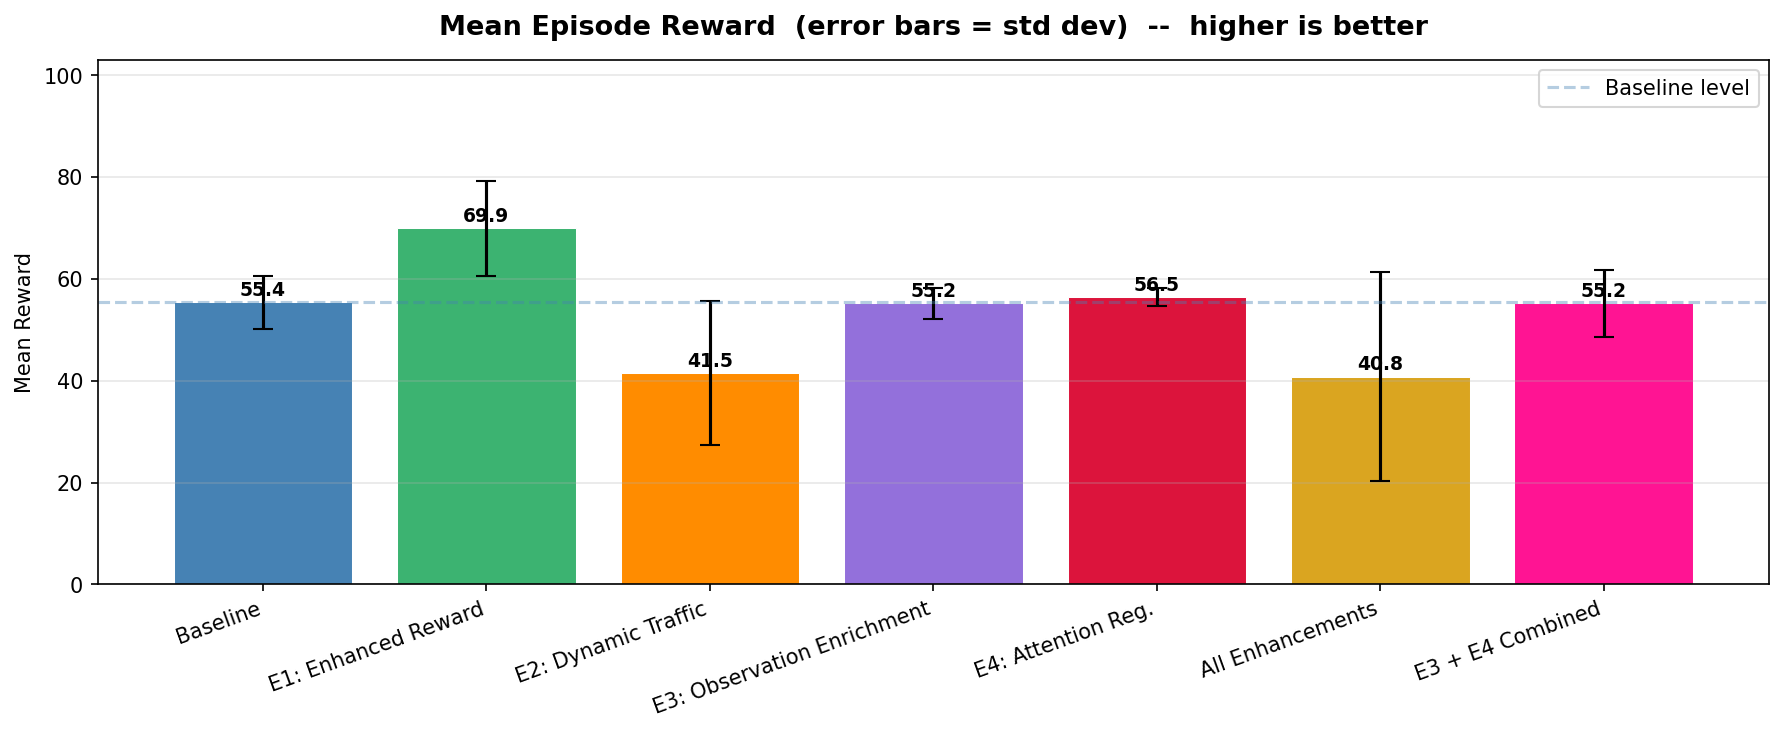

--- 2. Collision & Success Rates ---


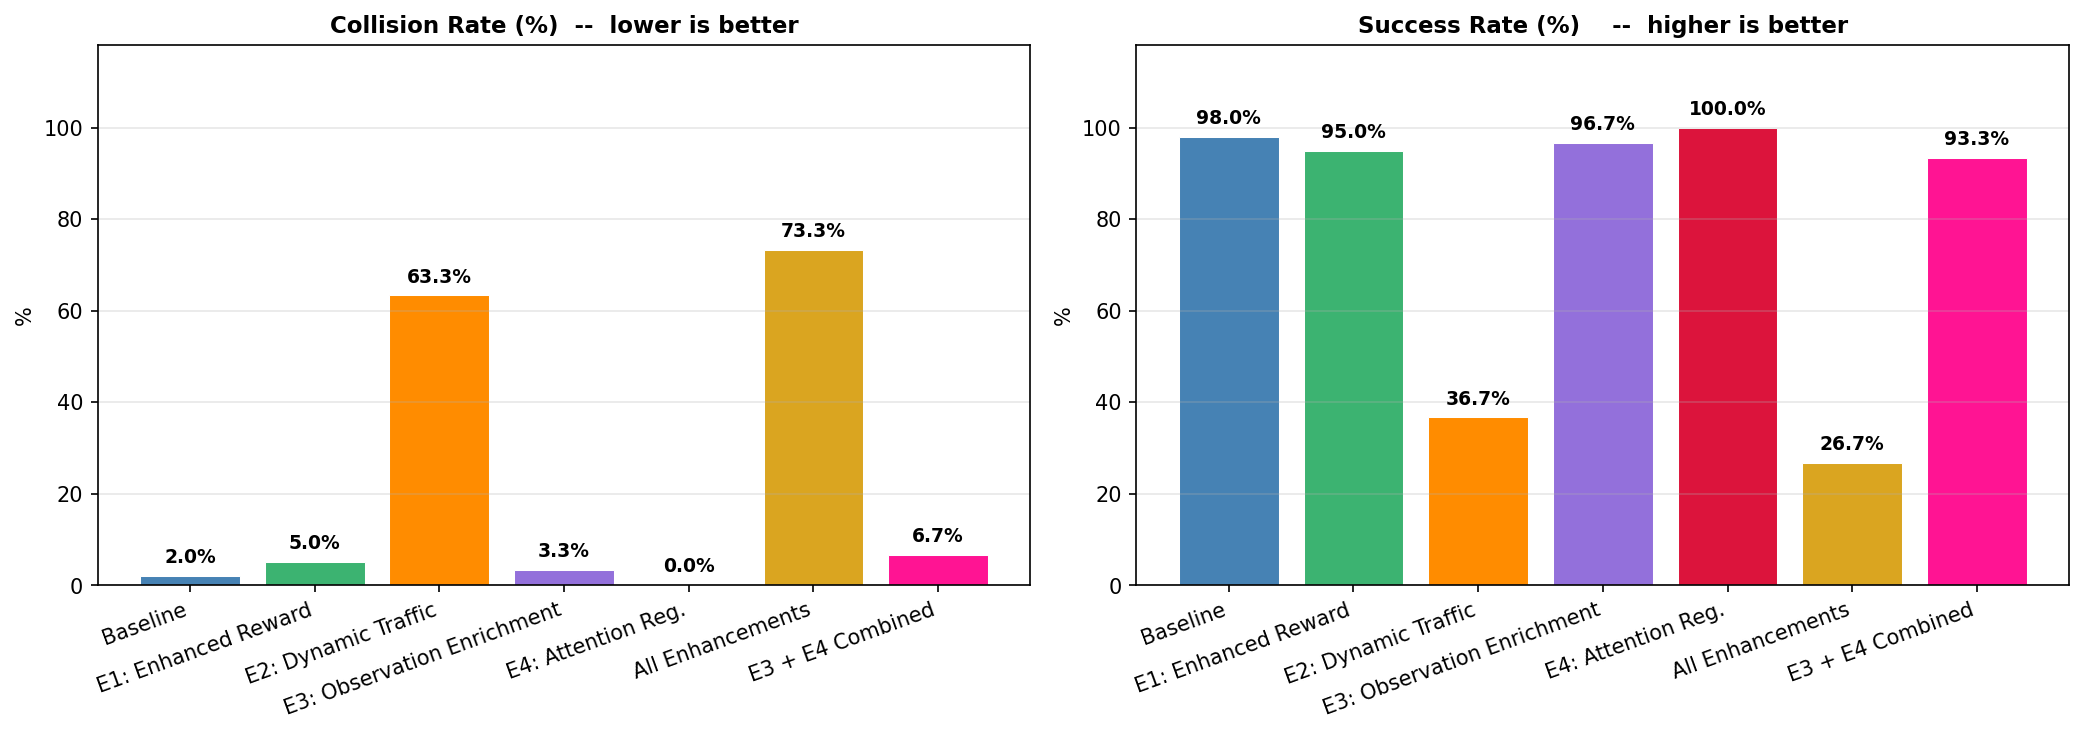

--- 3. Learning Curves ---


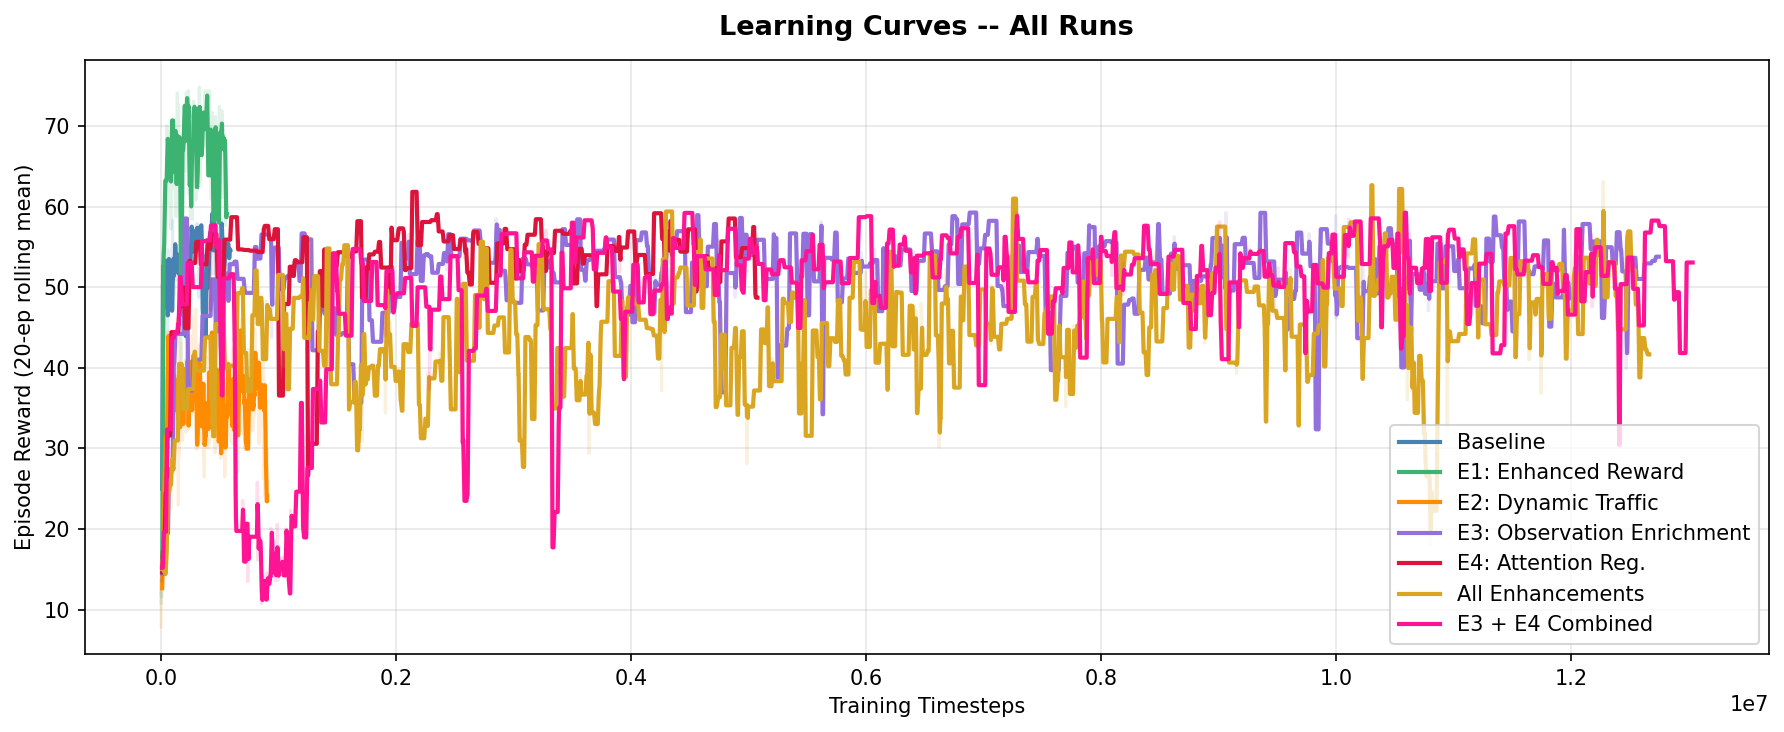

--- 4. Lane Deviation ---


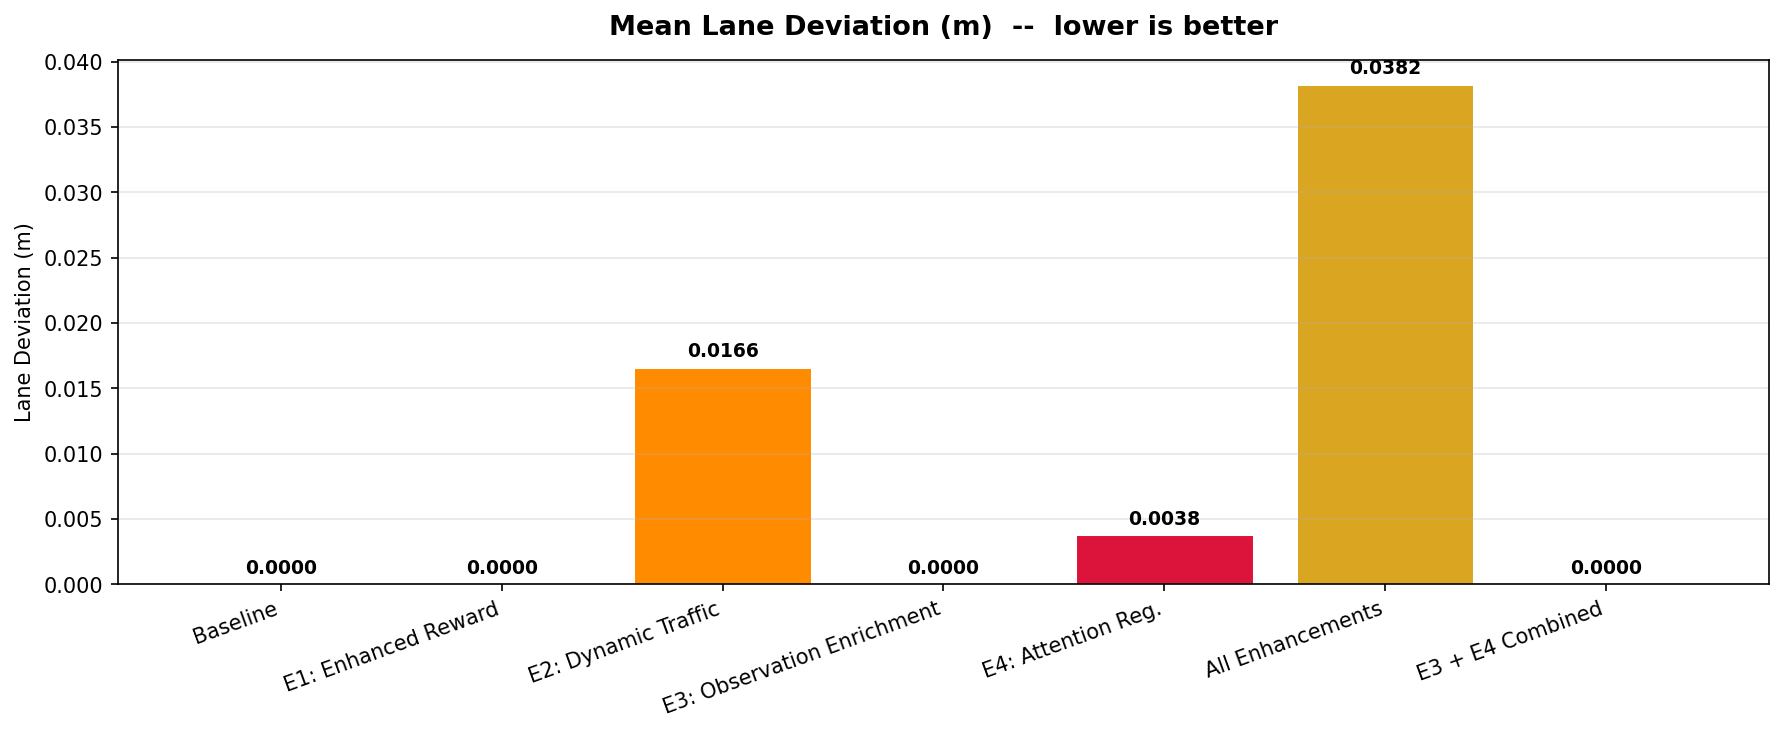


All comparison plots saved to ../ablation_results/


In [28]:
# Auto-load any run that has a saved metrics file but isn't in run_results yet
import glob as _glob, json as _json
for _r, _cfg in RUN_CONFIGS.items():
    if _r not in run_results:
        _mpath = os.path.join(RESULTS_DIR, f'{_r}_metrics.json')
        _lpath = os.path.join(LOG_DIR,     f'{_r}_reward_log.json')
        if os.path.exists(_mpath):
            with open(_mpath) as _f:
                _d = _json.load(_f)
            from src.evaluation.evaluation_metrics import AggregatedMetrics
            run_results[_r] = {
                'agg':        AggregatedMetrics(**{k: v for k, v in _d.items() if k in AggregatedMetrics.__dataclass_fields__}),
                'episodes':   [],
                'reward_log': _json.load(open(_lpath)) if os.path.exists(_lpath) else [],
                'label':      _cfg['label'],
                'color':      _cfg['color'],
            }

available = [r for r in RUN_CONFIGS if r in run_results]
labels    = [run_results[r]['label'] for r in available]
colors    = [run_results[r]['color'] for r in available]

if not available:
    print('No results yet -- run the evaluation cells above first.')
else:
    print(f'Comparing {len(available)} run(s): {labels}')
    print()

    def _smooth(data, w=10):
        return np.convolve(data, np.ones(w) / w, mode='valid')

    # ── 1. Mean Reward ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    means = [run_results[r]['agg'].mean_reward for r in available]
    stds  = [run_results[r]['agg'].std_reward  for r in available]
    bars  = ax.bar(labels, means, yerr=stds, color=colors,
                   capsize=5, edgecolor='white', linewidth=0.5)
    ax.axhline(means[0], color='steelblue', linestyle='--',
               alpha=0.4, label='Baseline level')
    ax.set_title('Mean Episode Reward  (error bars = std dev)  --  higher is better',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Mean Reward')
    ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.3)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{m:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'cmp_01_reward.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print('--- 1. Mean Reward ---')
    display(Image(filename=path))

    # ── 2. Collision & Success Rates ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cr = [run_results[r]['agg'].collision_rate for r in available]
    sr = [run_results[r]['agg'].success_rate   for r in available]
    for ax, title, vals in [
        (axes[0], 'Collision Rate (%)  --  lower is better',  cr),
        (axes[1], 'Success Rate (%)    --  higher is better', sr),
    ]:
        bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.5)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('%')
        ax.set_ylim(0, 118)
        ax.grid(True, axis='y', alpha=0.3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 2,
                    f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
        plt.sca(ax)
        plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'cmp_02_collision_success.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print('--- 2. Collision & Success Rates ---')
    display(Image(filename=path))

    # ── 3. Learning Curves ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for r in available:
        rl    = run_results[r]['reward_log']
        color = run_results[r]['color']
        label = run_results[r]['label']
        if not rl:
            continue
        steps = np.arange(len(rl)) * 1000
        ax.plot(steps, rl, alpha=0.15, color=color)
        if len(rl) >= 10:
            ax.plot(steps[9:], _smooth(rl), color=color,
                    linewidth=2, label=label)
    ax.set_xlabel('Training Timesteps')
    ax.set_ylabel('Episode Reward (20-ep rolling mean)')
    ax.set_title('Learning Curves -- All Runs',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'cmp_03_learning_curves.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print('--- 3. Learning Curves ---')
    display(Image(filename=path))

    # ── 4. Lane Deviation ─────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    devs = [run_results[r]['agg'].mean_lane_deviation for r in available]
    bars = ax.bar(labels, devs, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title('Mean Lane Deviation (m)  --  lower is better',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Lane Deviation (m)')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, devs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, 'cmp_04_lane_deviation.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print('--- 4. Lane Deviation ---')
    display(Image(filename=path))

    print(f'\nAll comparison plots saved to {RESULTS_DIR}/')


---
## Final Summary Table
All 8 metrics for every completed run, side by side.

In [30]:
# Auto-load any run that has a saved metrics file but isn't in run_results yet
import glob as _glob, json as _json
for _r, _cfg in RUN_CONFIGS.items():
    if _r not in run_results:
        _mpath = os.path.join(RESULTS_DIR, f'{_r}_metrics.json')
        _lpath = os.path.join(LOG_DIR,     f'{_r}_reward_log.json')
        if os.path.exists(_mpath):
            with open(_mpath) as _f:
                _d = _json.load(_f)
            from src.evaluation.evaluation_metrics import AggregatedMetrics
            run_results[_r] = {
                'agg':        AggregatedMetrics(**{k: v for k, v in _d.items() if k in AggregatedMetrics.__dataclass_fields__}),
                'episodes':   [],
                'reward_log': _json.load(open(_lpath)) if os.path.exists(_lpath) else [],
                'label':      _cfg['label'],
                'color':      _cfg['color'],
            }

available = [r for r in RUN_CONFIGS if r in run_results]

if not available:
    print('No results yet -- run the evaluation cells above first.')
else:
    col_w  = 22
    header = f"{'METRIC':<28}" + ''.join(
        f"{run_results[r]['label']:>{col_w}}" for r in available
    )
    sep = '=' * len(header)

    print()
    print(sep)
    print(header)
    print(sep)

    def _row(name, fn):
        row = f'{name:<28}'
        for r in available:
            row += f'{fn(run_results[r]["agg"]):>{col_w}}'
        return row

    rows = [
        _row('Mean Reward',       lambda a: f'{a.mean_reward:.1f} +/- {a.std_reward:.1f}'),
        _row('Collision Rate',    lambda a: f'{a.collision_rate:.1f} %'),
        _row('Success Rate',      lambda a: f'{a.success_rate:.1f} %'),
        _row('Mean Lane Dev (m)', lambda a: f'{a.mean_lane_deviation:.3f}'),
        _row('Max Lane Dev (m)',  lambda a: f'{a.max_lane_deviation:.3f}'),
        _row('Mean Speed (m/s)',  lambda a: f'{a.mean_speed:.2f}'),
        _row('Speed Variance',    lambda a: f'{a.speed_variance:.3f}'),
        _row('Mean Jerk',         lambda a: f'{a.mean_jerk:.4f}'),
        _row('Mean Distance (m)', lambda a: f'{a.mean_distance:.0f}'),
    ]

    for r in rows:
        print(r)
    print(sep)

    # ── Learning Efficiency ───────────────────────────────────────────────────
    print()
    print('Learning Efficiency  (timesteps to sustain mean reward > 30 over 10 episodes):')
    print()
    for r in available:
        rl  = run_results[r]['reward_log']
        eff = compute_learning_efficiency(
            rl, target_reward=30.0, window=10, timestep_interval=1000
        )
        val = f'{eff:,} timesteps' if eff else 'never reached target'
        print(f"  {run_results[r]['label']:<26}: {val}")



METRIC                                    Baseline   E1: Enhanced Reward   E2: Dynamic TrafficE3: Observation Enrichment    E4: Attention Reg.      All Enhancements      E3 + E4 Combined
Mean Reward                           55.4 +/- 5.2          69.9 +/- 9.3         41.5 +/- 14.2          55.2 +/- 3.1          56.5 +/- 1.8         40.8 +/- 20.5          55.2 +/- 6.5
Collision Rate                               2.0 %                 5.0 %                63.3 %                 3.3 %                 0.0 %                73.3 %                 6.7 %
Success Rate                                98.0 %                95.0 %                36.7 %                96.7 %               100.0 %                26.7 %                93.3 %
Mean Lane Dev (m)                            0.000                 0.000                 0.017                 0.000                 0.004                 0.038                 0.000
Max Lane Dev (m)                             0.000                 0.015        

## Hyperparameter Tuning -- E4: Attention Regularization

Runs **Bayesian optimization (Optuna TPE + MedianPruner)** over the PPO hyperparameter space
using the E4 configuration (attention regularization, 7-feature observation space).

**Why Optuna TPE?** Unlike random search, TPE learns from each completed trial to propose
configs in high-reward regions. The MedianPruner kills any trial whose running reward
falls below the median at each 50k-step checkpoint — concentrating budget on the best configs.

**Search space** (continuous where applicable):
| Hyperparameter | Range / Choices |
|---|---|
| `learning_rate` | log-uniform [1e-4, 5e-3] |
| `n_steps` | 512, 1024, 2048 |
| `batch_size` | divisors of n_steps from {32, 64, 128, 256} |
| `ent_coef` | log-uniform [1e-4, 0.1] |
| `gamma` | uniform [0.95, 0.999] |
| `gae_lambda` | uniform [0.90, 0.99] |
| `clip_range` | uniform [0.10, 0.30] |
| `n_epochs` | int [5, 20] |

**20 trials × 200k steps** with pruning at 50k / 100k / 150k checkpoints.
Bad configs are killed early; only top performers run to full budget.
Best config is then retrained cleanly for 200k steps.


In [ ]:
import sys
import os
SEED = 42
LOG_DIR = '../ablation_logs'
RESULTS_DIR = '../ablation_results'
sys.path.insert(0, "/home/jana2/autonomous_driving_project")
from src.training.hyperparameter_search import optuna_search, print_ranked_results
from src.models.custom_policy import AttentionRegularizedPPO
from scripts.train_enhanced import make_enhanced_env, _BASELINE_ATTN_KWARGS

_e4_enh = {
    'enhanced_reward': False, 'dynamic_traffic': False,
    'observation_enrichment': False, 'attention_reg': False,
}
e4_env_fn = lambda: make_enhanced_env(enhancements=_e4_enh, **env_kwargs)

_e4_model_kwargs = dict(
    lambda_high=0.01, lambda_low=0.01,
    n_observed_vehicles=10, enable_attention_reg=True,
)

best_hp, all_hp_results = optuna_search(
    env_fn=e4_env_fn,
    n_trials=20,
    total_timesteps=50_000,   # rank configs fast; best config retrains for 200k
    prune_freq=12_500,  # prune at 25%/50%/75% of 50k
    log_dir='hp_search_results/e4',
    seed=SEED,
    n_envs=8,   # 8 parallel envs per trial via SubprocVecEnv
    n_jobs=4,   # 4 concurrent trials  ->  ~32 cores in use at once
    policy_kwargs=dict(
        features_extractor_class=CustomExtractor,
        features_extractor_kwargs=_BASELINE_ATTN_KWARGS,
    ),
    model_class=AttentionRegularizedPPO,
    extra_model_kwargs=_e4_model_kwargs,
)

print_ranked_results(all_hp_results, top_n=5)
print('Best config:', best_hp)


In [ ]:
# Retrain E4 with the best hyperparameters found by Optuna -- run after the search cell
import os

HP_MODEL_PATH   = os.path.join(LOG_DIR,     "e4_hp_model")
HP_RL_PATH      = os.path.join(LOG_DIR,     "e4_hp_reward_log.json")
HP_METRICS_PATH = os.path.join(RESULTS_DIR, "e4_hp_metrics.json")
reward_log_hp   = []

env_hp = make_vec_env(e4_env_fn, n_envs=N_CPU, seed=SEED, vec_env_cls=SubprocVecEnv)

model_hp = AttentionRegularizedPPO(
    policy='MlpPolicy',
    env=env_hp,
    learning_rate=best_hp['learning_rate'],
    batch_size=best_hp['batch_size'],
    n_steps=max(best_hp['n_steps'] // N_CPU, best_hp['batch_size']),
    ent_coef=best_hp['ent_coef'],
    gamma=best_hp['gamma'],
    gae_lambda=best_hp['gae_lambda'],
    clip_range=best_hp['clip_range'],
    n_epochs=best_hp['n_epochs'],
    policy_kwargs=dict(
        features_extractor_class=CustomExtractor,
        features_extractor_kwargs=_BASELINE_ATTN_KWARGS,
    ),
    lambda_high=0.01, lambda_low=0.01,
    n_observed_vehicles=10, enable_attention_reg=True,
    verbose=1, device=DEVICE,
    tensorboard_log=os.path.join(LOG_DIR, "e4_hp_tb"),
)

model_hp.learn(
    total_timesteps=200_000,
    callback=[
        _LogRewards(reward_log_hp, HP_RL_PATH),
        CheckpointCallback(save_freq=50_000,
                           save_path=os.path.join(LOG_DIR, "e4_hp_ckpts")),
    ],
)
model_hp.save(HP_MODEL_PATH)
env_hp.close()

with open(HP_RL_PATH, "w") as f:
    json.dump(reward_log_hp, f)


In [ ]:
# Evaluate and compare with original E4
eval_env_hp = make_enhanced_env(enhancements=_e4_enh, **env_kwargs)
evaluator_hp = MetricsEvaluator(eval_env_hp, model_hp, n_episodes=N_EVAL_EPISODES)
agg_hp = evaluator_hp.evaluate()
eval_env_hp.close()
evaluator_hp.save_metrics(agg_hp, HP_METRICS_PATH)



  Episode  10/100 | reward=  32.54 | collided=True | recent_mean=45.62
  Episode  20/100 | reward=  58.77 | collided=False | recent_mean=48.74
  Episode  30/100 | reward=   4.85 | collided=True | recent_mean=35.93
  Episode  40/100 | reward=  49.20 | collided=True | recent_mean=36.50
  Episode  50/100 | reward=  48.37 | collided=True | recent_mean=26.92
  Episode  60/100 | reward=  20.87 | collided=True | recent_mean=30.52
  Episode  70/100 | reward=  34.40 | collided=True | recent_mean=34.13
  Episode  80/100 | reward=  25.17 | collided=True | recent_mean=47.33
  Episode  90/100 | reward=  58.77 | collided=False | recent_mean=37.04
  Episode 100/100 | reward=  58.77 | collided=False | recent_mean=31.14
Metrics saved → ../ablation_results\e4_hp_metrics.json


KeyError: 'e4_attn'

: 

: 

In [ ]:
import json
with open(f'{RESULTS_DIR}/e4_attn_metrics.json') as f:
    orig = json.load(f)
with open(HP_METRICS_PATH) as f:
    tuned = json.load(f)

print("Default E4  ->  reward={:.2f}  collision={:.0f}%  success={:.0f}%".format(orig['mean_reward'], orig['collision_rate'], orig['success_rate']))
print("Tuned E4    ->  reward={:.2f}  collision={:.0f}%  success={:.0f}%".format(tuned['mean_reward'], tuned['collision_rate'], tuned['success_rate']))


Default E4  ->  reward=55.91  collision=1%  success=99%
Tuned E4    ->  reward=37.39  collision=67%  success=33%


: 

: 